# Inventory resolution and hourly LCIA

SHRECC writes annual or monthly electricity inventories to Brightway. Hourly mixes remain calculation data: `NewDatabase.lcia()` assesses them directly without creating thousands of foreground activities.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from shrecc import NewDatabase

%load_ext jupyter_black

## Configuration

In [2]:
year = 2021
countries = ["ES"]
time_range = ["2021-01-01 00:00:00", "2021-06-30 23:00:00"]

project_name = "SHRECCei311"
bg_db_name = "ecoinvent-3.11-cutoff"
my_db_name = "spain_2021_monthly"

## Monthly inventories

Each month is aggregated and normalized independently. The configured `consumption_profile` supplies the weights within each month. Use the default `inventory_resolution="annual"` to create one inventory per country and year instead.

In [3]:
electricity = NewDatabase(
    years=year,
    countries=countries,
    time_range=time_range,
    project_name=project_name,
    bg_db_name=bg_db_name,
    my_db_name=my_db_name,
    inventory_resolution="monthly",
    consumption_profile="flat",
    include_consumption_mix_volume=False,
    retain_hourly_results=True,
)

In [4]:
electricity.create()
electricity.table().head()

C:\Users\Gibon\AppData\Local\Temp\ipykernel_3576\3803269410.py:1: UserWarning: Energy Charts activity mapping gaps for 2021 were assigned to source-country high-voltage production mixes. Fallback share by consumer: ES 1.5%. Largest source-technology gaps: ES/Waste non-renewable 1.0%, ES/Other renewables 0.3%, ES/Others 0.2%, FR/Waste non-renewable 0.0%, PT/Others 0.0%. See mapping_report(2021) for the full report.
  electricity.create()


time                                                                                   2021-01-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage electricity, high voltage kWh         0.0   

time                                                                                   2021-02-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage electricity, high voltage kWh         0.0   

time                                                                                   2021-03-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage electricity, high voltage kWh         0.0   

time                                                                                   2021-04-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage electricity, high voltage kWh         0.0   

time                                                                                   2021-05-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage e

In [6]:
electricity.write()

100%|██████████| 6/6 [00:00<00:00, 428.49it/s]


10:18:21+0200 [info     ] Vacuuming database            


NewDatabase(years=[2021], sources={2021:energy_charts})

## Hourly LCIA

With no explicit methods, SHRECC uses every installed method in the exact `EF v3.1` family. The default engine scores each unique background input once and combines these scores with the hourly coefficients.

In [7]:
assessment = electricity.lcia()

In [8]:
hourly = assessment.hourly()
annual = assessment.annual()
monthly = assessment.monthly()

In [9]:
# Calculation using the simple linear multiplication
gwp_linear = (
    hourly.to_dataframe()["intensity"]
    .xs(
        "ecoinvent-3.11 | EF v3.1 | climate change | global warming potential (GWP100)",
        level="impact_category",
    )
    .droplevel("consumer_country")
)

## Brightway-native validation

The optional MultiLCA engine expresses each hourly mix as a composite functional unit. It is slower and more memory-intensive than the linear engine, but useful for validation.

In [10]:
# Select a small method set before validating a long time range.
my_method = (
    "ecoinvent-3.11",
    "EF v3.1",
    "climate change",
    "global warming potential (GWP100)",
)

validated = electricity.lcia(methods=[my_method], engine="multilca")

In [11]:
validated.annual().to_dataframe()

,,,weighted_intensity
year,consumer_country,impact_category,
2021,ES,ecoinvent-3.11 | EF v3.1 | climate change | global warming potential (GWP100),0.170347


In [12]:
validated.monthly().to_dataframe()

weighted_intensity
year time       consumer_country impact_category                                                       
2021 2021-01-01 ES               ecoinvent-3.11 | EF v3.1 | climate change | glo...            0.165383
     2021-02-01 ES               ecoinvent-3.11 | EF v3.1 | climate change | glo...            0.125252
     2021-03-01 ES               ecoinvent-3.11 | EF v3.1 | climate change | glo...            0.150514
     2021-04-01 ES               ecoinvent-3.11 | EF v3.1 | climate change | glo...            0.197523
     2021-05-01 ES               ecoinvent-3.11 | EF v3.1 | climate change | glo...            0.169825
     2021-06-01 ES               ecoinvent-3.11 | EF v3.1 | climate change | glo...            0.211423

[Text(0, 0, '2021-01-01 00:00:00'),
 Text(1, 0, '2021-02-01 00:00:00'),
 Text(2, 0, '2021-03-01 00:00:00'),
 Text(3, 0, '2021-04-01 00:00:00'),
 Text(4, 0, '2021-05-01 00:00:00'),
 Text(5, 0, '2021-06-01 00:00:00')]

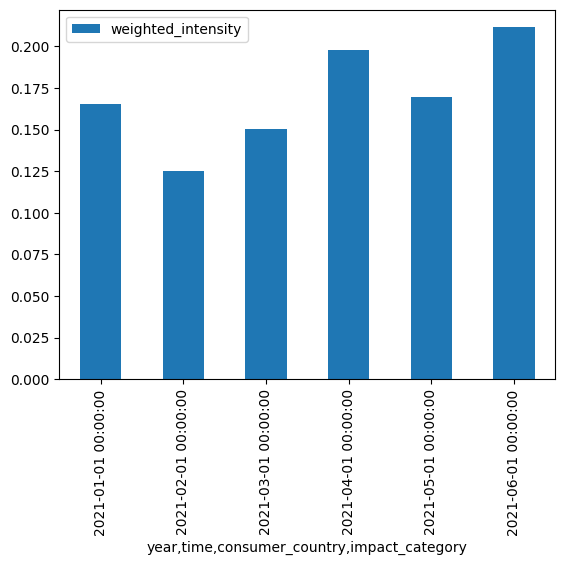

In [13]:
ax = validated.monthly().to_dataframe().plot.bar()
ax.set_xticklabels(validated.monthly().get_index("time"))

In [14]:
gwp_bw = (
    validated.hourly()
    .to_dataframe()["intensity"]
    .droplevel(["consumer_country", "impact_category"])
)

Text(0, 0.5, 'kg CO2 eq./kWh')

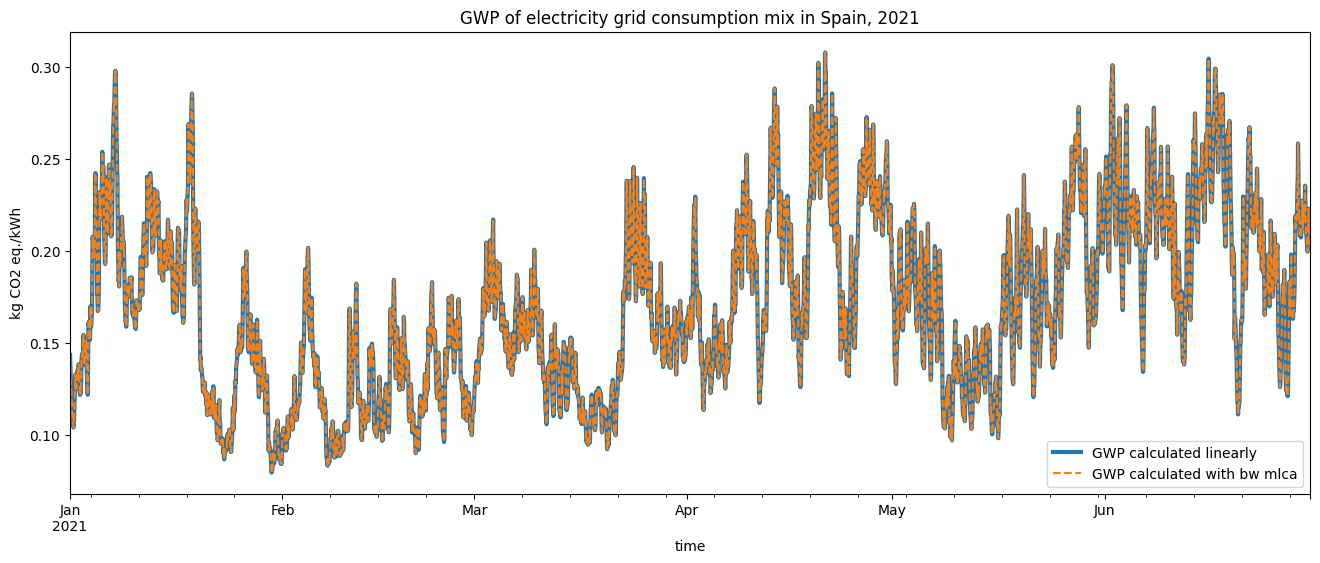

In [15]:
ax = gwp_linear.plot(figsize=(16, 6), linewidth=3)
gwp_bw.plot(ax=ax, linestyle="--")
ax.legend(["GWP calculated linearly", "GWP calculated with bw mlca"])
ax.set_title("GWP of electricity grid consumption mix in Spain, 2021")
ax.set_ylabel("kg CO2 eq./kWh")

# For fun, compare selected European grids in 2025
Inventories are written annually by default, while `.lcia()` retains the hourly environmental profiles used below.

In [ ]:
europe_2025 = NewDatabase(
    years=[2025],
    countries=[ # this is the top 20 for 2025
        "DE",
        "FR",
        "UK",
        "IT",
        "ES",
        "PL",
        "NO",
        "SE",
        "NL",
        "FI",
        "BE",
        "CZ",
        "CH",
        "AT",
        "RO",
        "PT",
        "GR",
        "HU",
        "BG",
        "DK",
    ],
    time_range=["2025-01-01 00:00", "2025-12-31 23:00"],
    project_name=project_name,
    bg_db_name=bg_db_name,
    my_db_name="europe_2025",
    consumption_profile="flat",
)

In [40]:
europe_2025.create()

C:\Users\Gibon\AppData\Local\Temp\ipykernel_3576\2548743311.py:1: UserWarning: Energy Charts activity mapping gaps for 2025 were assigned to source-country high-voltage production mixes. Fallback share by consumer: NL 35.4%, NO 18.1%, BE 13.5%, RO 12.8%, UK 8.0%. Largest source-technology gaps: NL/Others 32.4%, NO/Hydro run-of-river 17.2%, BE/Others 7.4%, RO/Hydro 7.1%, IT/Others 5.8%. See mapping_report(2025) for the full report.
  europe_2025.create()


NewDatabase(years=[2025], sources={2025:energy_charts})

In [41]:
lcia_europe = europe_2025.lcia()

## GWP

In [42]:
gwp_method = (
    "ecoinvent-3.11 | EF v3.1 | climate change | global warming potential (GWP100)"
)

In [48]:
eu_2025_gwp_g = 1000 * (
    lcia_europe.hourly()["intensity"]
    .sel(impact_category=gwp_method)
    .to_dataframe()["intensity"]
    .unstack("consumer_country")
)
country_colors = dict(zip(eu_2025_gwp_g.columns, plt.get_cmap("tab20").colors))
annual_gwp_means_g = (
    1000 * lcia_europe.annual().sel(year=2025, impact_category=gwp_method).to_series()
)

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'Hourly GHG intensity and seven-day rolling mean in selected European countries'}, ylabel='g CO2 eq./kWh'>)

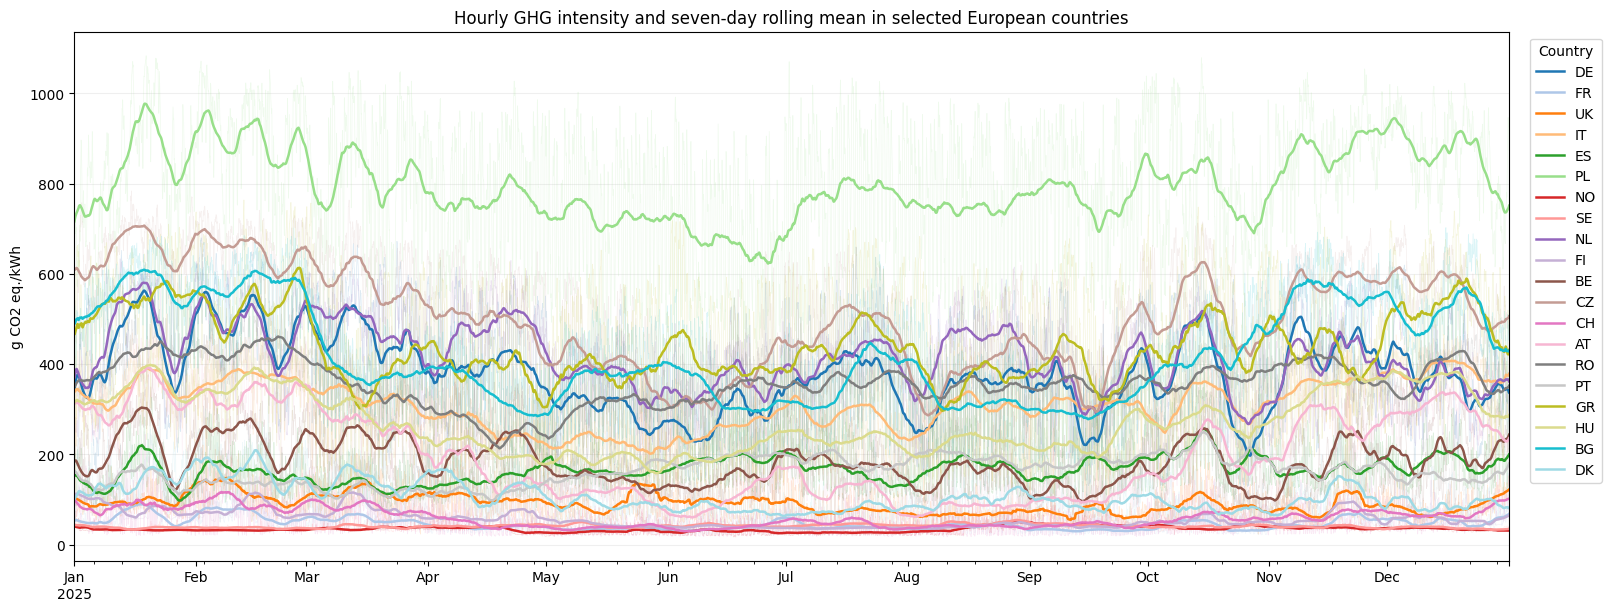

In [ ]:
def plot_hourly_and_rolling(hourly_values, *, title, ylabel):
    """Plot faint hourly values beneath their seven-day rolling means."""
    colors = [country_colors[country] for country in hourly_values.columns]
    weekly_values = hourly_values.rolling(24 * 7, center=True, min_periods=24).mean()

    fig, ax = plt.subplots(figsize=(16, 6), layout="constrained")
    hourly_values.plot(
        ax=ax,
        color=colors,
        linewidth=0.5,
        alpha=0.15,
        legend=False,
    )
    weekly_values.plot(
        ax=ax,
        color=colors,
        linewidth=1.8,
        legend=False,
    )
    weekly_lines = ax.lines[-len(hourly_values.columns) :]
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(None)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(
        weekly_lines,
        hourly_values.columns,
        title="Country",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
    )
    return fig, ax


def plot_duration_and_distribution(hourly_values, annual_means, *, title, ylabel):
    """
    Plot duration curves and country-level hourly distributions.
    Keep `annual_means` separate from `hourly_values` because it can be calculated with a different weighting.
    It can be recalculated from `hourly_values` only if `consumption_profile="flat"`.
    """
    duration_curve = hourly_values.transform(np.sort).iloc[::-1].reset_index(drop=True)
    duration_curve.index = np.linspace(0, 100, len(duration_curve))
    country_order = annual_means.sort_values().index
    position_step = 1.4
    positions = np.arange(len(country_order)) * position_step

    fig, (ax_curve, ax_distribution) = plt.subplots(
        ncols=2,
        figsize=(18, 6),
        gridspec_kw={"width_ratios": [3, 2.4]},
        layout="constrained",
        sharey=True,
    )
    duration_curve.plot(
        ax=ax_curve,
        color=[country_colors[country] for country in duration_curve.columns],
        linewidth=1.6,
        legend=False,
    )
    ax_curve.set_title(title)
    ax_curve.set_xlabel("Share of year (%)")
    ax_curve.set_ylabel(ylabel)
    ax_curve.set_xlim(0, 100)
    ax_curve.grid(alpha=0.2)

    violins = ax_distribution.violinplot(
        [hourly_values[country].dropna().to_numpy() for country in country_order],
        positions=positions,
        orientation="vertical",
        widths=0.7,
        showextrema=False,
        showmedians=True,
        # density_norm="area",
    )
    for body, country in zip(violins["bodies"], country_order):
        body.set_facecolor(country_colors[country])
        body.set_edgecolor(country_colors[country])
        body.set_alpha(0.65)
    violins["cmedians"].set_color("white")
    violins["cmedians"].set_linewidth(1.2)

    mean_values = annual_means.loc[country_order]
    ax_distribution.scatter(
        positions,
        mean_values,
        color=[country_colors[country] for country in country_order],
        edgecolor="white",
        linewidth=0.8,
        marker="D",
        s=35,
        zorder=3,
    )
    for position, country, value in zip(positions, country_order, mean_values):
        ax_distribution.annotate(
            f"{value:.3g}",
            (position, value),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            color=country_colors[country],
            fontsize=9,
            fontweight="semibold",
            clip_on=False,
        )
    ax_distribution.set_xticks(positions, country_order)
    ax_distribution.set_xlim(-0.6, positions[-1] + 1.1)
    ax_distribution.set_title("Hourly distribution\n(diamond: annual mean)")
    ax_distribution.set_ylabel(ylabel)
    ax_distribution.grid(axis="y", alpha=0.2)
    return fig, (ax_curve, ax_distribution)


plot_hourly_and_rolling(
    eu_2025_gwp_g,
    title=(
        "Hourly GHG intensity and seven-day rolling mean in selected "
        "European countries"
    ),
    ylabel="g CO2 eq./kWh",
)

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: title={'center': 'GHG-intensity duration curves for selected European countries, grid consumption mix, 2025'}, xlabel='Share of year (%)', ylabel='g CO2 eq./kWh'>,
  <Axes: title={'center': 'Hourly distribution\n(diamond: annual mean)'}, ylabel='g CO2 eq./kWh'>))

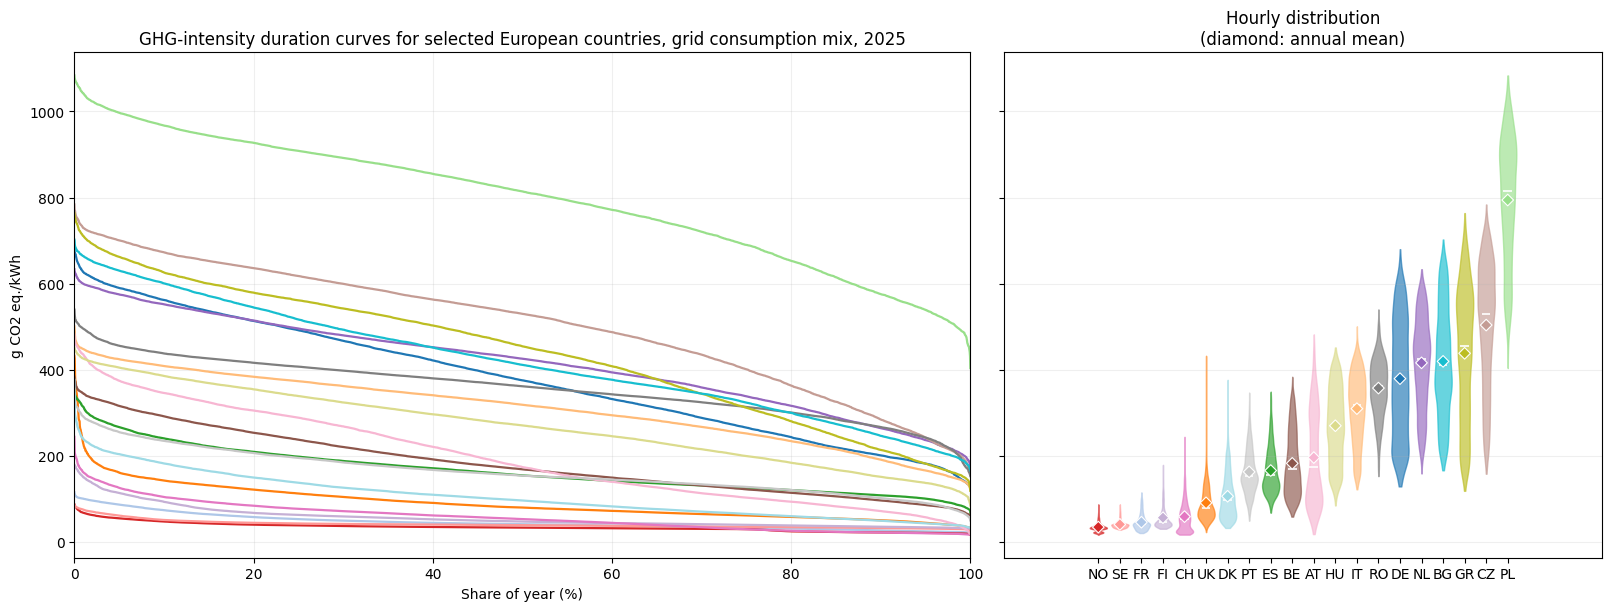

In [54]:
plot_duration_and_distribution(
    eu_2025_gwp_g,
    annual_gwp_means_g,
    title="GHG-intensity duration curves for selected European countries, grid consumption mix, 2025",
    ylabel="g CO2 eq./kWh",
)

## Material depletion

In [ ]:
material_method = "ecoinvent-3.11 | EF v3.1 | material resources: metals/minerals | abiotic depletion potential (ADP): elements (ultimate reserves)"

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: title={'center': 'Material-depletion duration curves for selected European countries'}, xlabel='Share of year (%)', ylabel='mg Sb eq./kWh'>,
  <Axes: title={'center': 'Hourly distribution\n(diamond: annual mean)'}, xlabel='mg Sb eq./kWh'>))

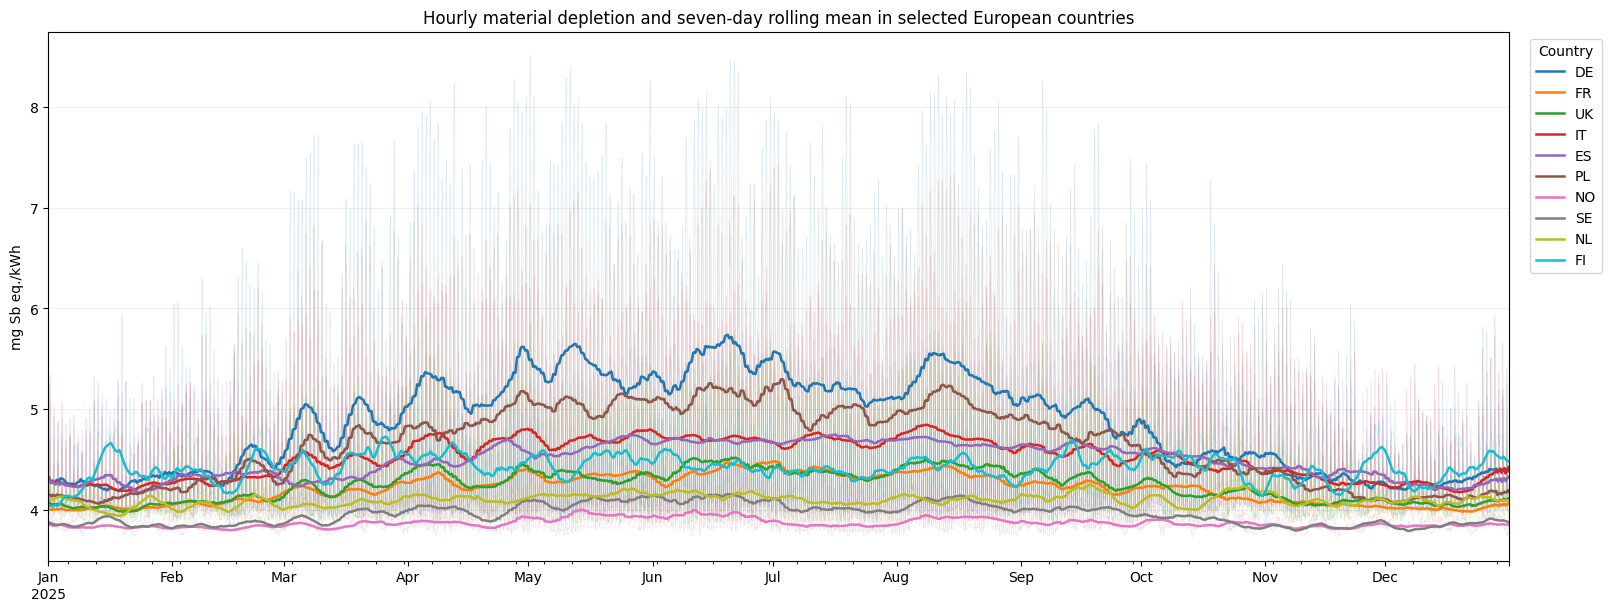

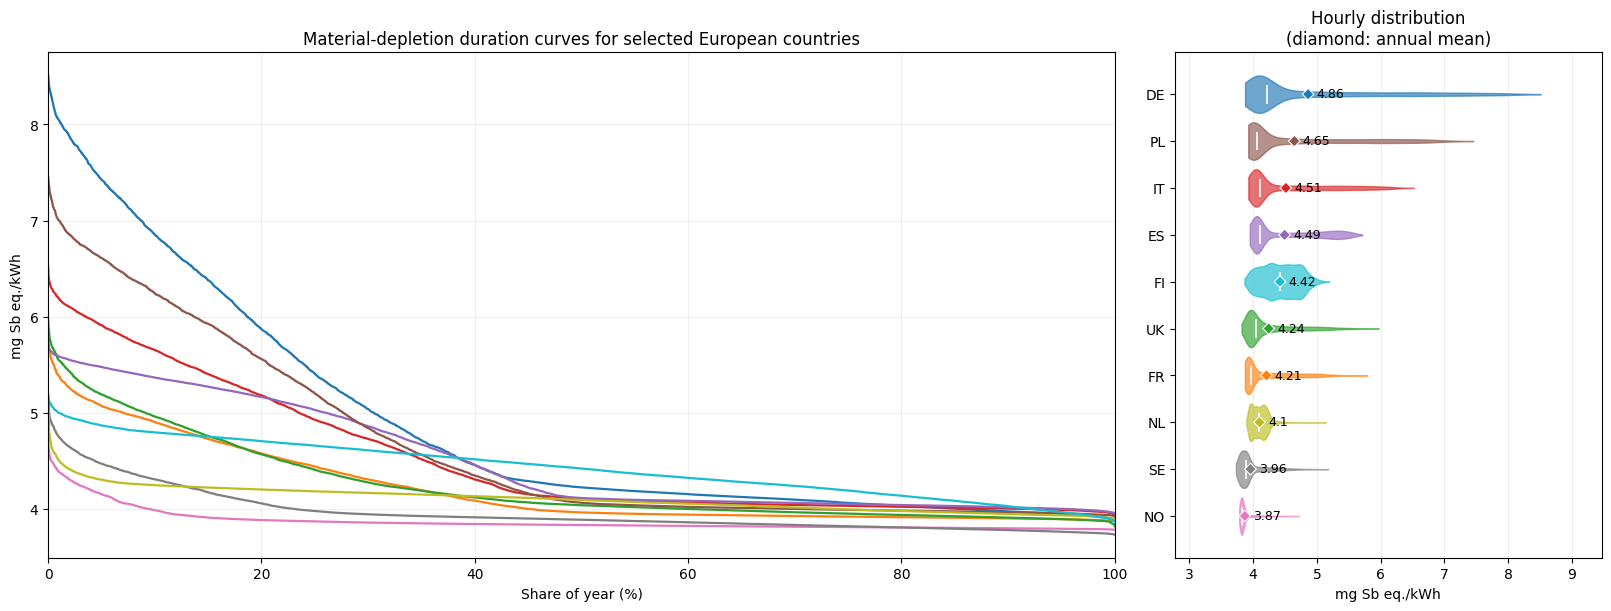

In [ ]:
eu_2025_material_mg = 1e6 * (
    lcia_europe.hourly()["intensity"]
    .sel(impact_category=material_method)
    .to_dataframe()["intensity"]
    .unstack("consumer_country")
)
annual_material_means_mg = (
    1e6
    * lcia_europe.annual().sel(year=2025, impact_category=material_method).to_series()
)

plot_hourly_and_rolling(
    eu_2025_material_mg,
    title=(
        "Hourly material depletion and seven-day rolling mean in selected "
        "European countries"
    ),
    ylabel="mg Sb eq./kWh",
)
plot_duration_and_distribution(
    eu_2025_material_mg,
    annual_material_means_mg,
    title=("Material-depletion duration curves for selected European countries"),
    ylabel="mg Sb eq./kWh",
)

## GWP vs. material depletion
The faint cloud shows hourly combinations. Country labels identify the flat-weighted annual means; the dashed line and correlation summarize this small selected-country sample and should not be interpreted causally.

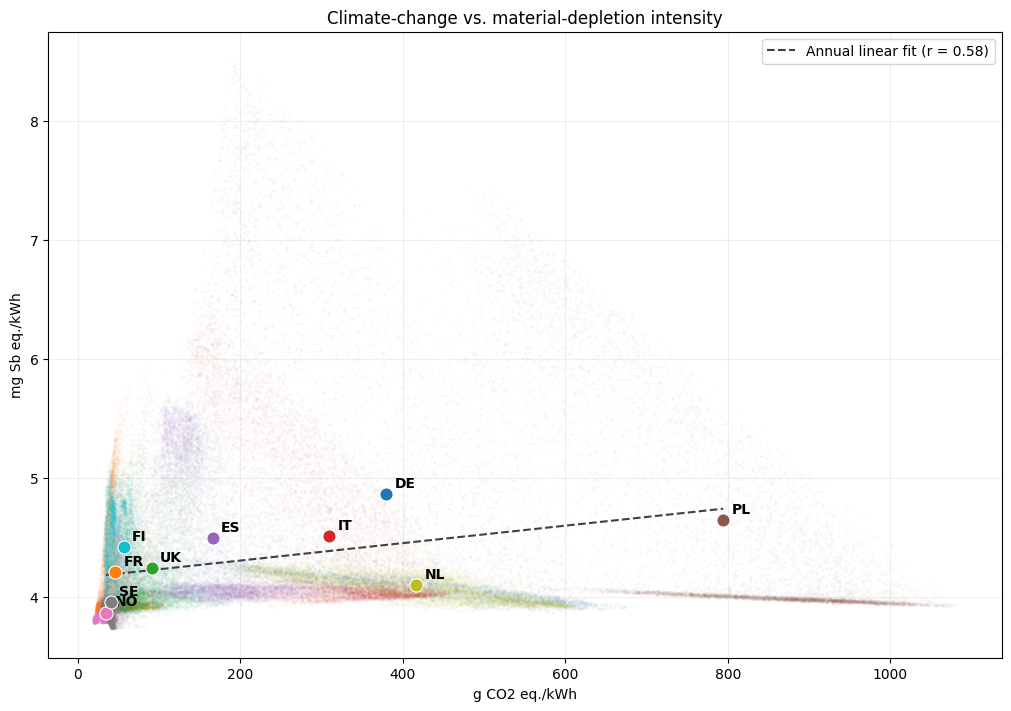

: 

In [ ]:
annual_tradeoff = annual_gwp_means_g.to_frame("gwp").join(
    annual_material_means_mg.rename("material")
)
annual_correlation = annual_tradeoff["gwp"].corr(annual_tradeoff["material"])
slope, intercept = np.polyfit(annual_tradeoff["gwp"], annual_tradeoff["material"], 1)
fit_x = np.linspace(annual_tradeoff["gwp"].min(), annual_tradeoff["gwp"].max(), 100)

fig, ax = plt.subplots(figsize=(10, 7), layout="constrained")
for country in eu_2025_gwp_g.columns:
    ax.scatter(
        eu_2025_gwp_g[country],
        eu_2025_material_mg[country],
        color=country_colors[country],
        s=5,
        alpha=0.025,
        linewidth=0,
        rasterized=True,
    )

for country, values in annual_tradeoff.iterrows():
    ax.scatter(
        values["gwp"],
        values["material"],
        color=country_colors[country],
        edgecolor="white",
        linewidth=0.8,
        s=90,
        zorder=3,
    )
    ax.annotate(
        country,
        (values["gwp"], values["material"]),
        xytext=(6, 5),
        textcoords="offset points",
        weight="bold",
    )

ax.plot(
    fit_x,
    slope * fit_x + intercept,
    color="0.25",
    linestyle="--",
    linewidth=1.5,
    label=f"Annual linear fit (r = {annual_correlation:.2f})",
)
ax.set_title("Climate-change vs. material-depletion intensity")
ax.set_xlabel("g CO2 eq./kWh")
ax.set_ylabel("mg Sb eq./kWh")
ax.grid(alpha=0.2)
ax.legend(loc="best")